In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.float_format', '{:.4f}'.format)
con = duckdb.connect('C:/Users/kweec/python_files/risk-project/notebooks/credit_risk.db')
df = con.execute("SELECT * FROM mart.features").df()



                  id   is_default    loan_amnt  installment   annual_inc  \
count   1341110.0000 1341110.0000 1341110.0000 1341110.0000 1341110.0000   
mean   56238359.8649       0.1997   14394.8430     437.2950   75018.3690   
min       54734.0000       0.0000     500.0000       4.9300     600.0000   
25%    19947865.7500       0.0000    7975.0000     248.3000   46000.0000   
50%    57682849.5000       0.0000   12000.0000     374.7500   65000.0000   
75%    84456851.5000       0.0000   20000.0000     578.7900   90000.0000   
max   145636374.0000       1.0000   40000.0000    1719.8300  499992.0000   
std    38309724.4492       0.3997    8697.5999     260.8214   45064.8798   

               dti     fico_avg     open_acc   revol_util    total_acc  \
count 1341110.0000 1341110.0000 1341110.0000 1340262.0000 1341110.0000   
mean       18.1542     698.1572      11.5900      51.8077      24.9723   
min        -1.0000     627.0000       0.0000       0.0000       2.0000   
25%        11.8100 

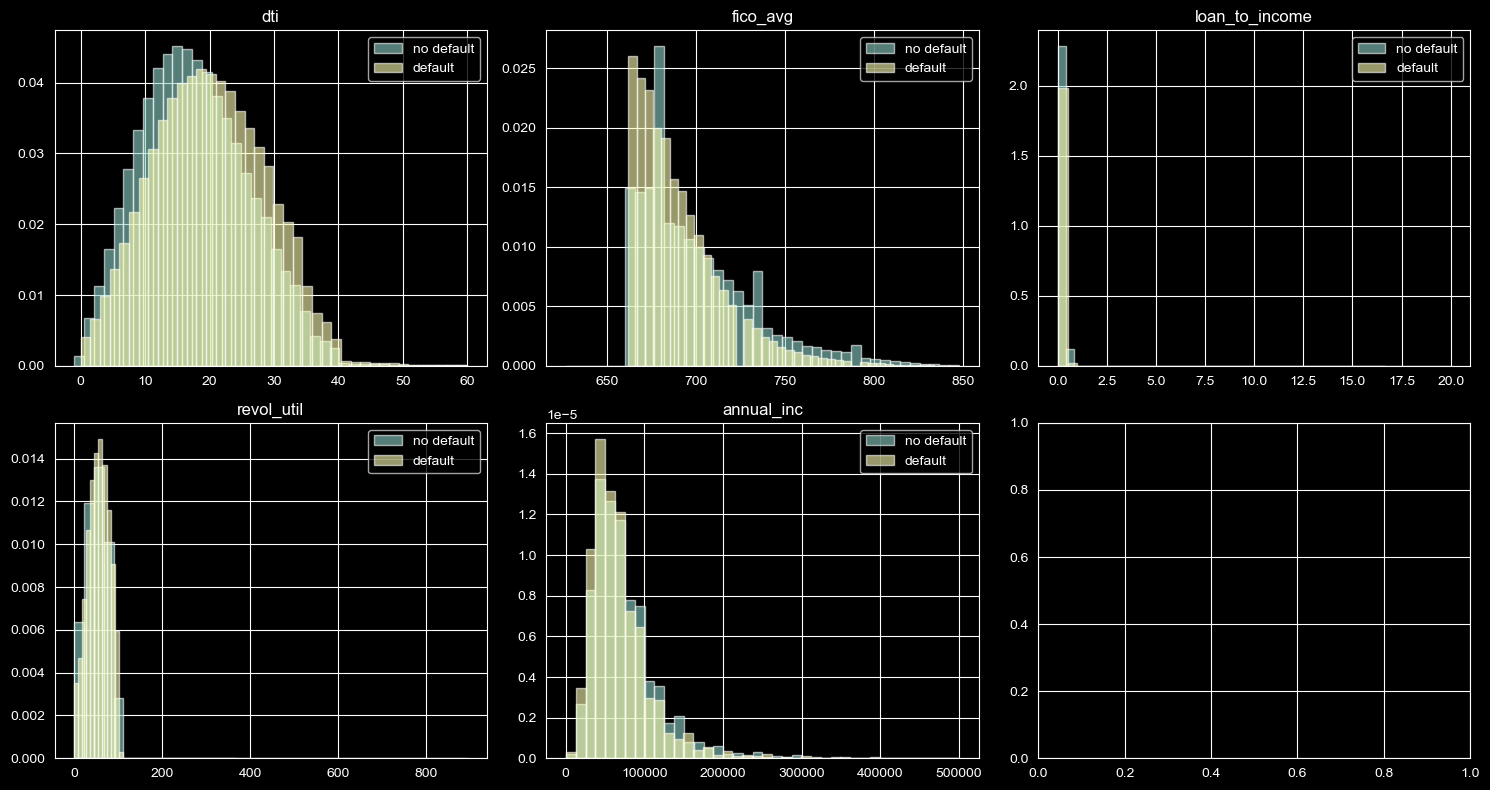

In [2]:
# 1. Базовая статистика
print(df.describe())

# 2. Распределение PD по ключевым фичам
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

features = ['dti', 'fico_avg',
            'loan_to_income', 'revol_util', 'annual_inc']

for ax, feat in zip(axes.flat, features):
    df.groupby('is_default')[feat].hist(
        bins=40, alpha=0.6, ax=ax, density=True
    )
    ax.set_title(feat)
    ax.legend(['no default', 'default'])

plt.tight_layout()
plt.show()

In [3]:
# 3. Дефолтность по категориям
for col in ['home_ownership', 'purpose', 'term_months']:
    print(f"\n--- {col} ---")
    print(
        df.groupby(col)['is_default']
        .agg(['mean', 'count'])
        .sort_values('mean', ascending=False)
        .round(3)
    )

# 4. Корреляция с таргетом
print("\nКорреляция фич с is_default:")
print(
    df[features + ['is_default'] + ['term_months']]
    .corr()['is_default']
    .sort_values(ascending=False)
    .round(3)
)


--- home_ownership ---
                 mean   count
home_ownership               
RENT           0.2320  533496
OWN            0.2060  144357
ANY            0.1960     286
OTHER          0.1890     143
MORTGAGE       0.1720  662781
NONE           0.1490      47

--- purpose ---
                     mean   count
purpose                          
small_business     0.2970   15329
renewable_energy   0.2380     929
moving             0.2340    9447
house              0.2200    7222
medical            0.2180   15507
debt_consolidation 0.2110  778083
other              0.2100   77589
vacation           0.1920    9048
major_purchase     0.1860   29317
home_improvement   0.1780   86962
educational        0.1720     326
credit_card        0.1690  294507
car                0.1470   14555
wedding            0.1220    2289

--- term_months ---
              mean    count
term_months                
60          0.3250   323369
36          0.1600  1017741

Корреляция фич с is_default:
is_default  

In [4]:
con.close()